In [60]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import mlflow
import mlflow.tensorflow

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

BASE_DIR      = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR     = os.path.join(BASE_DIR, 'models')
DB_PATH       = os.path.join(BASE_DIR, 'mlflow.db')
os.makedirs(MODEL_DIR, exist_ok=True)

mlflow.set_tracking_uri(f'sqlite:///{DB_PATH}')
mlflow.set_experiment('RaksaDana-LSTM')

print(f'TensorFlow : {tf.__version__}')
print(f'MLflow     : {mlflow.__version__}')
print(f'PROCESSED  : {PROCESSED_DIR}')
print(f'MODEL_DIR  : {MODEL_DIR}')
print(f'Tracking   : {mlflow.get_tracking_uri()}')

TensorFlow : 2.21.0
MLflow     : 3.12.0
PROCESSED  : c:\Users\akbar\VSCode Project\RaksaDana\data\processed
MODEL_DIR  : c:\Users\akbar\VSCode Project\RaksaDana\models
Tracking   : sqlite:///c:\Users\akbar\VSCode Project\RaksaDana\mlflow.db


In [61]:
with open(os.path.join(PROCESSED_DIR, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

sequences     = data['sequences']
scalers       = data['scalers']
feature_cols  = data['feature_cols']
target_col    = data['target_col']
target_idx    = data['target_idx']
window_size   = data['window_size']
tickers       = data['tickers']
featured_data = data['featured_data']

# Drop fitur konstan ROE/EPS/DY (tidak ada sinyal temporal).
# Sebelumnya di-mask jadi 0; sekarang langsung di-slice supaya dimensi LSTM lebih bersih.
DROP_COLS        = ['ROE', 'EPS', 'DY']
DROP_IDX         = [feature_cols.index(c) for c in DROP_COLS if c in feature_cols]
KEEP_IDX         = [i for i in range(len(feature_cols)) if i not in DROP_IDX]
feature_cols_new = [feature_cols[i] for i in KEEP_IDX]

# Update target_idx baru (Close ada di posisi 3, tidak berubah karena ROE/EPS/DY ada SETELAH Close)
target_idx_new   = feature_cols_new.index(target_col)

for ticker in tickers:
    sequences[ticker]['X_train'] = sequences[ticker]['X_train'][:, :, KEEP_IDX]
    sequences[ticker]['X_test']  = sequences[ticker]['X_test'][:,  :, KEEP_IDX]

print(f'Tickers       : {tickers}')
print(f'Features lama : {len(feature_cols)}')
print(f'Features baru : {len(feature_cols_new)}  → {feature_cols_new}')
print(f'Target        : {target_col} (idx baru = {target_idx_new})')
print(f'Window size   : {window_size}')
for t in tickers:
    s = sequences[t]
    print(f'{t} -> X_train {s["X_train"].shape}  X_test {s["X_test"].shape}')


Tickers       : ['BBCA.JK', 'BBRI.JK', 'BMRI.JK']
Features lama : 20
Features baru : 17  → ['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA20', 'MA50', 'RSI', 'BB_upper', 'BB_lower', 'BB_width', 'Daily_Return', 'Log_Return', 'Volume_MA7', 'MACD', 'MACD_signal']
Target        : Close (idx baru = 3)
Window size   : 60
BBCA.JK -> X_train (1100, 60, 17)  X_test (276, 60, 17)
BBRI.JK -> X_train (1100, 60, 17)  X_test (276, 60, 17)
BMRI.JK -> X_train (1100, 60, 17)  X_test (276, 60, 17)


## Model Architecture

In [62]:
from tensorflow.keras.layers import LayerNormalization

def build_lstm(input_shape, lr=5e-4, units=(64, 32), dropout=0.2, l2_reg=1e-5):
    """
    Arsitektur LSTM v2:
    - BatchNorm → LayerNorm (kompatibel dengan recurrence)
    - L2 1e-4 → 1e-5, recurrent_regularizer dihapus
    - Dropout 0.3 → 0.2
    - Loss Huber (robust terhadap outlier harga)
    - Output: scaled Close[t] (target sama seperti versi original — direkonstruksi via inverse_scaler)
    """
    model = Sequential([
        LSTM(units[0], return_sequences=True, input_shape=input_shape,
             kernel_regularizer=l2(l2_reg)),
        LayerNormalization(),
        Dropout(dropout),

        LSTM(units[1], return_sequences=False,
             kernel_regularizer=l2(l2_reg)),
        LayerNormalization(),
        Dropout(dropout),

        Dense(8, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='huber',
        metrics=['mae']
    )
    return model

sample_shape = (window_size, len(feature_cols_new))
print(f'Input shape: {sample_shape}')
build_lstm(sample_shape).summary()


Input shape: (60, 17)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_40 (LSTM)                  │ (None, 60, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_16          │ (None, 60, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_17          │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,873 (132.32 KB)

 Trainable params: 33,873 (132.32 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [ ]:
EPOCHS = 100

# Per-ticker config: BMRI dapat kapasitas lebih besar + LR lebih kecil (atasi underfit chronic)
TICKER_CONFIG = {
    'BBCA.JK': {'lr': 1e-3, 'units': (64, 32), 'batch': 32, 'dropout': 0.20},
    'BBRI.JK': {'lr': 5e-4, 'units': (64, 32), 'batch': 32, 'dropout': 0.20},
    'BMRI.JK': {'lr': 3e-4, 'units': (96, 48), 'batch': 16, 'dropout': 0.15},
}

# Experiment baru di MLflow
mlflow.set_experiment('RaksaDana-LSTM-v2')

histories = {}
models    = {}

for ticker in tickers:
    print(f'\n{"="*50}')
    print(f'Training: {ticker}')
    print(f'{"="*50}')

    cfg     = TICKER_CONFIG[ticker]
    s       = sequences[ticker]

    X_train = s['X_train']           # shape (1100, 60, 17)
    X_test  = s['X_test']            # shape (276,  60, 17)
    y_train = s['y_train']           # scaled Close[t]
    y_test  = s['y_test']

    # Temporal val split eksplisit (last 10% dari train) — shuffle=False wajib
    val_split    = int(len(X_train) * 0.9)
    X_tr, X_val  = X_train[:val_split], X_train[val_split:]
    y_tr, y_val  = y_train[:val_split], y_train[val_split:]

    input_shape = (window_size, X_train.shape[2])
    model       = build_lstm(input_shape, lr=cfg['lr'],
                             units=cfg['units'], dropout=cfg['dropout'])

    ckpt_path = os.path.join(MODEL_DIR, f'lstm_{ticker.replace(".","_")}_best.keras')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=25,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=10, min_lr=1e-6, verbose=1),
        ModelCheckpoint(ckpt_path, monitor='val_loss',
                        save_best_only=True, verbose=0),
    ]

    with mlflow.start_run(run_name=ticker):
        mlflow.log_params({
            'ticker'       : ticker,
            'lstm_units'   : str(cfg['units']),
            'epochs'       : EPOCHS,
            'batch_size'   : cfg['batch'],
            'learning_rate': cfg['lr'],
            'dropout'      : cfg['dropout'],
            'l2_reg'       : 1e-5,
            'window_size'  : window_size,
            'n_features'   : X_train.shape[2],
            'target'       : 'scaled_close',
            'loss'         : 'huber',
            'norm_layer'   : 'LayerNormalization',
            'es_patience'  : 25,
            'validation'   : 'temporal_last_10pct',
        })

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),   # temporal, bukan random
            epochs=EPOCHS,
            batch_size=cfg['batch'],
            callbacks=callbacks,
            shuffle=False,                    # WAJIB time series
            verbose=1,
        )

        for epoch, (loss, val_loss, mae, val_mae) in enumerate(zip(
            history.history['loss'],     history.history['val_loss'],
            history.history['mae'],      history.history['val_mae'],
        )):
            mlflow.log_metrics({
                'train_loss': loss,
                'val_loss'  : val_loss,
                'train_mae' : mae,
                'val_mae'   : val_mae,
            }, step=epoch)

        mlflow.log_artifact(ckpt_path)

    histories[ticker] = history.history
    models[ticker]    = model
    print(f'Saved: {ckpt_path}')



Training: BBCA.JK
Epoch 1/100


## Training Curves

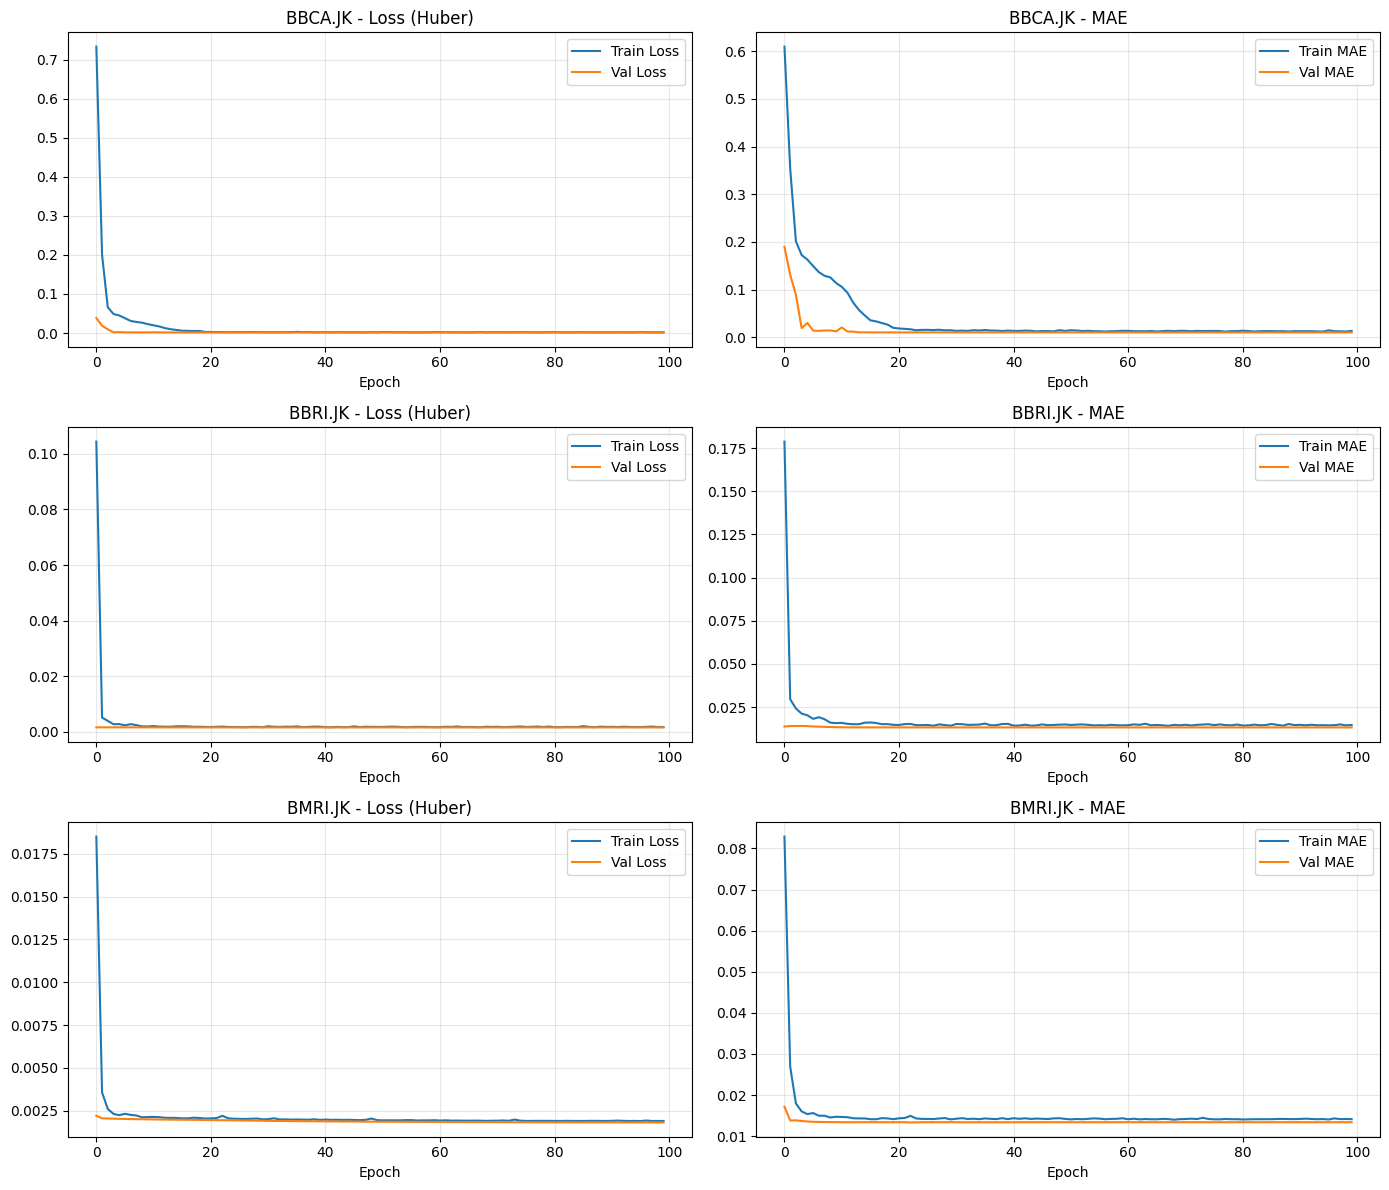

In [ ]:
fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    h = histories[ticker]

    axes[i, 0].plot(h['loss'],     label='Train Loss')
    axes[i, 0].plot(h['val_loss'], label='Val Loss')
    axes[i, 0].set_title(f'{ticker} - Loss (Huber)')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(h['mae'],     label='Train MAE')
    axes[i, 1].plot(h['val_mae'], label='Val MAE')
    axes[i, 1].set_title(f'{ticker} - MAE')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

## Inverse-Transform Predictions

In [ ]:
def inverse_close(scaler, scaled_values, n_features, target_idx):
    """Inverse-transform hanya kolom Close.  scaler dilatih pada 20 fitur (sebelum drop),
    jadi kita konstruksi dummy array 20-dim, isi kolom target, lalu inverse."""
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

predictions = {}
n_feat_orig = len(feature_cols)  # 20 — sesuai scaler yang di-fit di notebook 02

for ticker in tickers:
    s      = sequences[ticker]
    scaler = scalers[ticker]
    model  = models[ticker]

    y_pred_train = model.predict(s['X_train'], verbose=0)
    y_pred_test  = model.predict(s['X_test'],  verbose=0)

    predictions[ticker] = {
        'y_train_true': inverse_close(scaler, s['y_train'],   n_feat_orig, target_idx),
        'y_train_pred': inverse_close(scaler, y_pred_train,   n_feat_orig, target_idx),
        'y_true'      : inverse_close(scaler, s['y_test'],    n_feat_orig, target_idx),
        'y_pred'      : inverse_close(scaler, y_pred_test,    n_feat_orig, target_idx),
    }

print('Inverse transform selesai.')


## Evaluation Metrics

In [ ]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

rows = []
for ticker in tickers:
    p = predictions[ticker]
    rows.append({'Ticker': ticker, 'Split': 'Train', **evaluate(p['y_train_true'], p['y_train_pred'])})
    rows.append({'Ticker': ticker, 'Split': 'Test',  **evaluate(p['y_true'],       p['y_pred'])})

metrics_df = pd.DataFrame(rows).set_index(['Ticker', 'Split'])
metrics_df = metrics_df.round({'MAE': 2, 'RMSE': 2, 'MAPE': 4, 'R2': 4})

display(
    metrics_df.style
    .background_gradient(subset=['MAE','RMSE','MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2'], cmap='RdYlGn')
    .format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}%', 'R2': '{:.4f}'})
)


## Prediction vs Actual

In [ ]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 5 * len(tickers)))

for i, ticker in enumerate(tickers):
    p     = predictions[ticker]
    ax    = axes[i]
    dates = featured_data[ticker].index
    split = len(p['y_train_true'])

    train_dates = dates[window_size : window_size + split]
    test_dates  = dates[window_size + split : window_size + split + len(p['y_true'])]

    ax.plot(train_dates, p['y_train_true'], color='steelblue', alpha=0.4, lw=1,   label='Train Actual')
    ax.plot(train_dates, p['y_train_pred'], color='orange',    alpha=0.7, lw=1,   label='Train Pred')
    ax.plot(test_dates,  p['y_true'],       color='steelblue', alpha=0.9, lw=1.5, label='Test Actual')
    ax.plot(test_dates,  p['y_pred'],       color='crimson',   alpha=0.9, lw=1.5, label='Test Pred')
    ax.axvline(train_dates[-1], color='gray', linestyle='--', lw=1, alpha=0.6)

    m  = evaluate(p['y_true'], p['y_pred'])
    da = da_df.loc[ticker, 'Model DA (%)']
    ax.set_title(
        f"{ticker}  |  RMSE: {m['RMSE']:,.0f}  MAE: {m['MAE']:,.0f}  "
        f"MAPE: {m['MAPE']:.2f}%  R²: {m['R2']:.4f}  DA: {da:.1f}%"
    )
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'prediction_vs_actual.png'), dpi=120, bbox_inches='tight')
plt.show()


## Test Set Zoom

In [ ]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    p     = predictions[ticker]
    ax    = axes[i]
    dates = featured_data[ticker].index
    split = len(p['y_train_true'])
    test_dates = dates[window_size + split : window_size + split + len(p['y_true'])]

    ax.plot(test_dates, p['y_true'], color='steelblue', lw=1.5, label='Actual')
    ax.plot(test_dates, p['y_pred'], color='crimson',   lw=1.5, label='Predicted', linestyle='--')
    ax.fill_between(test_dates, p['y_pred'] * 0.98, p['y_pred'] * 1.02,
                    color='crimson', alpha=0.08, label='±2% band')

    da_val = da_df.loc[ticker, 'Model DA (%)']
    ax.set_title(f'{ticker} — Test Set Prediction  |  DA: {da_val:.1f}%')
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'test_zoom.png'), dpi=120, bbox_inches='tight')
plt.show()


## Residual Analysis

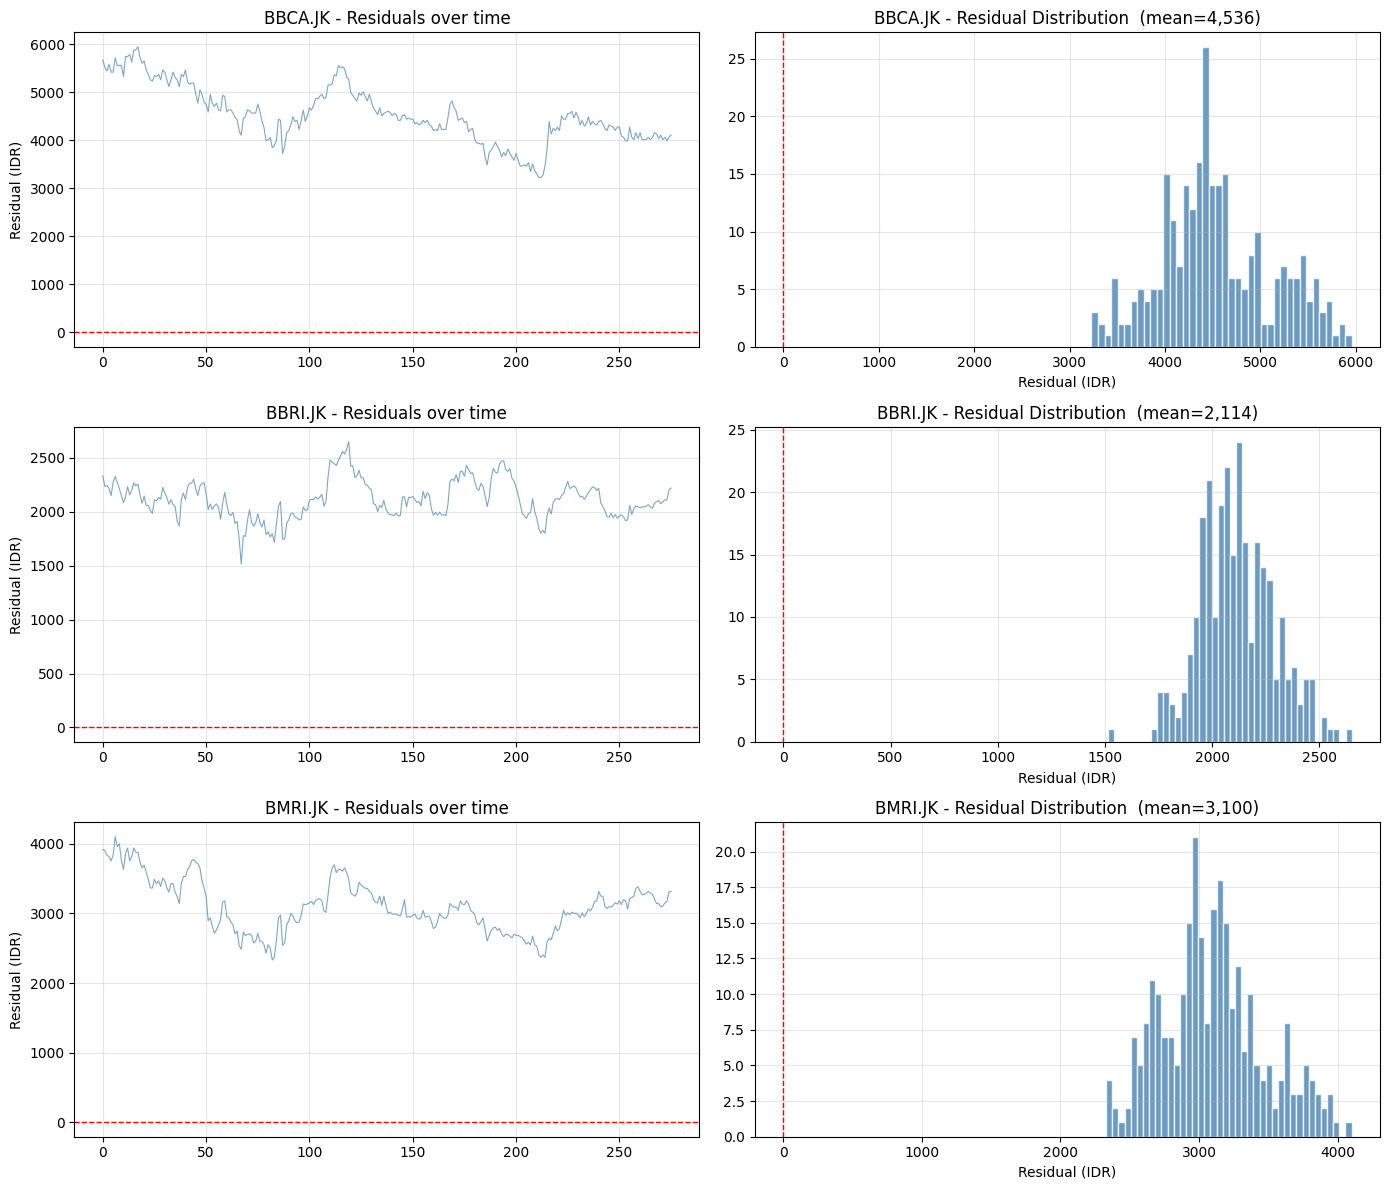

In [ ]:
fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    p         = predictions[ticker]
    residuals = p['y_true'] - p['y_pred']

    axes[i, 0].plot(residuals, color='steelblue', lw=0.8, alpha=0.7)
    axes[i, 0].axhline(0, color='red', linestyle='--', lw=1)
    axes[i, 0].set_title(f'{ticker} - Residuals over time')
    axes[i, 0].set_ylabel('Residual (IDR)')
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 1].axvline(0, color='red', linestyle='--', lw=1)
    axes[i, 1].set_title(f'{ticker} - Residual Distribution  (mean={residuals.mean():,.0f})')
    axes[i, 1].set_xlabel('Residual (IDR)')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'residuals.png'), dpi=120, bbox_inches='tight')
plt.show()

## Directional Accuracy

In [ ]:
da_rows = []
for ticker in tickers:
    p = predictions[ticker]

    actual_dir = np.sign(np.diff(p['y_true']))
    pred_dir   = np.sign(np.diff(p['y_pred']))

    # Model DA
    da_model = (actual_dir == pred_dir).mean() * 100

    # Baseline persistence: prediksi close[t] = close[t-1], jadi diff = 0 → sign = 0
    # DA persistence dihitung dengan asumsi prediksi diff = 0 (sign tidak match dengan +1/-1)
    # Lebih tepat: pakai sign dari diff close aktual lag 1 (random direction)
    persistence_dir = np.zeros_like(actual_dir)
    da_persist      = (actual_dir == persistence_dir).mean() * 100

    da_rows.append({
        'Ticker'                : ticker,
        'Model DA (%)'          : round(da_model, 2),
        'Persistence DA (%)'    : round(da_persist, 2),
        'Model > Persistence?'  : '✓' if da_model > da_persist else '✗',
    })


In [ ]:
da_df = pd.DataFrame(da_rows).set_index('Ticker')
display(
    da_df.style
    .background_gradient(subset=['Model DA (%)'], cmap='RdYlGn', vmin=40, vmax=70)
    .applymap(lambda v: 'color: green; font-weight: bold' if v == '✓'
              else ('color: red' if v == '✗' else ''),
              subset=['Model > Persistence'])
)


## Diagnostic D.2 — Ljung-Box Residual Test

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

print('Ljung-Box test pada residual close (test set)')
print('H0: residual = white noise.  Good fit jika p > 0.10 di lag 10\n')

lb_rows = []
for ticker in tickers:
    p         = predictions[ticker]
    residuals = p['y_true'] - p['y_pred']
    lb        = acorr_ljungbox(residuals, lags=[5, 10, 20], return_df=True)
    print(f'{ticker}:')
    print(lb.round(4))
    print()
    for lag, row in lb.iterrows():
        lb_rows.append({
            'Ticker'         : ticker,
            'Lag'            : int(lag),
            'LB stat'        : round(row['lb_stat'], 4),
            'p-value'        : round(row['lb_pvalue'], 4),
            'Lulus (p>0.10)' : '✓' if row['lb_pvalue'] > 0.10 else '✗',
        })

lb_df = pd.DataFrame(lb_rows).set_index(['Ticker', 'Lag'])
display(
    lb_df.style
    .applymap(lambda v: 'color: green; font-weight: bold' if v == '✓'
              else ('color: red' if v == '✗' else ''),
              subset=['Lulus (p>0.10)'])
)


## Diagnostic D.3 — KS-Test Feature Distribution Shift (Train vs Test)

In [ ]:
from scipy.stats import ks_2samp

print('KS-test: feature distribution train vs test')
print('Warning jika p < 0.01 — distribusi berubah signifikan antar split\n')

ks_rows = []
for ticker in tickers:
    s          = sequences[ticker]
    train_flat = s['X_train'].reshape(-1, s['X_train'].shape[2])  # (n*60, 17)
    test_flat  = s['X_test'].reshape(-1,  s['X_test'].shape[2])

    print(f'{ticker}:')
    for i, col in enumerate(feature_cols_new):
        stat, pval = ks_2samp(train_flat[:, i], test_flat[:, i])
        flag = ' ← SHIFT' if pval < 0.01 else ''
        print(f'  {col:18s}  KS={stat:.3f}  p={pval:.4f}{flag}')
        ks_rows.append({
            'Ticker' : ticker,
            'Feature': col,
            'KS stat': round(stat, 3),
            'p-value': round(pval, 4),
            'Shift?' : '✗ SHIFT' if pval < 0.01 else '✓ OK',
        })
    print()

ks_df = pd.DataFrame(ks_rows).set_index(['Ticker', 'Feature'])
n_shift = (ks_df['Shift?'] == '✗ SHIFT').sum()
print(f'Total fitur dengan distribusi shift signifikan (p<0.01): {n_shift}')
print('(< 3 = acceptable; >= 3 = pertimbangkan rolling re-train di iterasi berikutnya)')


## Diagnostic D.4 — Permutation Feature Importance

In [ ]:
print('Permutation Feature Importance (test set, MSE scaled close)')
print('Semakin tinggi nilai, semakin penting fitur tersebut.\n')

imp_all = {}
rng = np.random.RandomState(42)

for ticker in tickers:
    s         = sequences[ticker]
    model     = models[ticker]
    X_test    = s['X_test']
    y_true    = s['y_test']

    base_pred = model.predict(X_test, verbose=0).flatten()
    base_mse  = mean_squared_error(y_true, base_pred)

    importances = []
    for i, col in enumerate(feature_cols_new):
        X_perm = X_test.copy()
        flat   = X_perm[:, :, i].flatten()
        rng.shuffle(flat)
        X_perm[:, :, i] = flat.reshape(X_perm.shape[0], X_perm.shape[1])

        perm_pred = model.predict(X_perm, verbose=0).flatten()
        perm_mse  = mean_squared_error(y_true, perm_pred)
        importances.append({'Feature': col, 'Importance': round(perm_mse - base_mse, 8)})

    imp_df = pd.DataFrame(importances).sort_values('Importance', ascending=False)
    imp_all[ticker] = imp_df
    print(f'{ticker}:')
    print(imp_df.to_string(index=False))
    print()

# Bar chart
fig, axes = plt.subplots(1, len(tickers), figsize=(16, 5))
for ax, ticker in zip(axes, tickers):
    df = imp_all[ticker].sort_values('Importance')
    ax.barh(df['Feature'], df['Importance'], color='steelblue', alpha=0.8)
    ax.axvline(0, color='red', lw=0.8, linestyle='--')
    ax.set_title(f'{ticker} — Feature Importance')
    ax.set_xlabel('MSE increase when shuffled')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'feature_importance.png'), dpi=120, bbox_inches='tight')
plt.show()


## 30-Day Forecast

In [ ]:
FORECAST_DAYS = 30

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    s      = sequences[ticker]
    scaler = scalers[ticker]
    model  = models[ticker]
    ax     = axes[i]

    last_window     = s['X_test'][-1].copy()   # (60, 17)
    forecast_scaled = []

    for _ in range(FORECAST_DAYS):
        pred = float(model.predict(last_window[np.newaxis], verbose=0)[0, 0])
        forecast_scaled.append(pred)

        # Geser window: update kolom Close (target_idx_new = 3) di step baru
        new_step                   = last_window[-1].copy()
        new_step[target_idx_new]   = pred
        last_window                = np.vstack([last_window[1:], new_step])

    # Inverse Close: pakai n_feat_orig (20) untuk kompatibilitas scaler
    forecast = inverse_close(scaler, np.array(forecast_scaled), n_feat_orig, target_idx)

    last_actuals = predictions[ticker]['y_true'][-60:]
    last_dates   = featured_data[ticker].index[-60:]
    future_dates = pd.bdate_range(
        start=last_dates[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS
    )

    ax.plot(last_dates,   last_actuals, color='steelblue', lw=1.5, label='Last 60d actual')
    ax.plot(future_dates, forecast,     color='crimson',   lw=2,
            label=f'{FORECAST_DAYS}-day forecast', linestyle='--')
    ax.fill_between(future_dates, forecast * 0.97, forecast * 1.03,
                    color='crimson', alpha=0.1, label='±3% band')
    ax.axvline(last_dates[-1], color='gray', linestyle=':', lw=1)
    ax.set_title(f'{ticker} — {FORECAST_DAYS}-Day Price Forecast')
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'forecast_30d.png'), dpi=120, bbox_inches='tight')
plt.show()


## Summary

In [ ]:
print('Final Test Metrics (v2 — Close target + arsitektur baru)')
print('=' * 70)

test_metrics = metrics_df.xs('Test', level='Split')
display(
    test_metrics.style.format(
        {'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}%', 'R2': '{:.4f}'}
    )
)

print('\nDirectional Accuracy vs Baseline Persistence')
display(da_df)

# Log final metric ke MLflow
for ticker in tickers:
    runs = mlflow.search_runs(
        experiment_names=['RaksaDana-LSTM-v2'],
        filter_string=f"tags.mlflow.runName = '{ticker}'",
        order_by=['start_time DESC'],
    )
    if not runs.empty:
        with mlflow.start_run(run_id=runs.iloc[0].run_id):
            m  = test_metrics.loc[ticker]
            da = da_df.loc[ticker, 'Model DA (%)']
            mlflow.log_metrics({
                'test_mae'  : m['MAE'],
                'test_rmse' : m['RMSE'],
                'test_mape' : m['MAPE'],
                'test_r2'   : m['R2'],
                'test_da'   : da,
            })

print(f'\nMLflow UI:')
print(f'  mlflow ui --backend-store-uri sqlite:///{DB_PATH} --workers 1')
print(f'  buka http://127.0.0.1:5000  (experiment: RaksaDana-LSTM-v2)')
print(f'\nModels saved:')
for ticker in tickers:
    p = os.path.join(MODEL_DIR, f'lstm_{ticker.replace(".", "_")}_best.keras')
    print(f'  {p}')
